# Solving the Maxcut Problem with QAOA

**Download this notebook - {nb-download}`qaoa_maxcut_example.ipynb`**


In this notebook tutorial we will be demonstrating how to solve the maxcut problem using the quantum approximate optimization algorithm (QAOA). This is a variational algorithm where we run a parameterised circuit to compute an expectation value. We will then try and maximise this expectation value by classically optimizing the circuit parameters.


## The Max-Cut problem

The maxcut problem is a classic problem from graph theory. The problem consists of partitioning the nodes in a graph into two sets $R$ and $B$ such that the number of edges between $R$ and $B$ is maximised. In our statement of the problem, we will colour the nodes red and blue. The objective for maxcut is then to colour the nodes of the graph such that the number of edges connecting red nodes to blue nodes is maximised.


Now consider the graph below with three nodes.


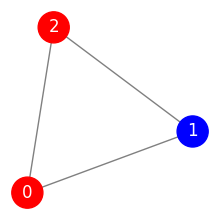

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()
G.add_edges_from([(0, 1), (1, 2), (2, 0)])
plt.figure(figsize=(2, 2))
nx.draw(
    G,
    node_color=["red", "blue", "red"],
    font_size=12,
    font_color="white",
    node_size=500,
    edge_color="gray",
    with_labels=True,
)
plt.show()

There are $2^3$ colourings of the graph. In general there are $2^n$ for an $n$ node graph. The Max-cut problem can then be stated as that of finding the colour assignment which maximises the number of edges between nodes of a different colour.



We can define the following cost function for solving the maxcut problem for a graph $G$

$$
\begin{equation*}
C(G)= \frac{1}{2}\sum_{(i,j) \in E(G)} (1-z_i\,z_j)\,, \quad z_i,z_j \in \{-1,1\}
\end{equation*}
$$

Here $z_i$ and $z_j$ are variables representing the "colours" of each node and $E(G)$ is the edge set of the graph.




## Quantum Approximate Optimization Algorithm (QAOA)

Introduced in "A Quantum Approximate Optimization Algorithm" (found at https://arxiv.org/abs/1411.4028). The idea is to prepare a quantum state which encodes a solution to the max-cut problem. Measuring such a state will give us computational basis states (or bitstrings) which correspond to colourings of the graph. 


QAOA is a variational algorithm, which is to say that a parameterized state is prepared, with the parameters varied to improve the solution. We will have $2p$ parameters where $p$ is our number of layers. In particular, the state prepared has the form 


$$
| \psi  ( \beta, \gamma ) \rangle = U_B ( \beta_{p-1} ) U_P ( \gamma_{p-1} ) ... U_B (\beta_0) U_P ( \gamma_0 ) | +\rangle ^{\otimes n}
$$

where

$$
U_P ( \gamma_i) = e^{i \gamma_i H_P} \quad \& \quad U_B( \beta_i ) = e^{i \beta_i H_B}
$$

For the simple three node graph above the *problem Hamiltonian* is

$$
H_{P(G)} = \frac{3}{2} I - \frac{1}{2} \Big[ ( Z \otimes Z \otimes I ) + ( Z \otimes I \otimes Z ) + ( I \otimes Z \otimes Z ) \Big]
$$

where you will notice that there is a $ Z \otimes Z$ acting between each node which is connected by an edge.
The *mixer Hamiltonian* has the form 

$$
H_B =   ( X \otimes I \otimes I ) + ( I \otimes X \otimes I ) + ( I \otimes I \otimes X )
$$

Here there is an $X$ operator acting on each node. The form of this operator is independent of the graph.


The Pauli $Z$ operator can be used to distinguish between the $|0\rangle$ and $|1\rangle$ basis states as these are eigenstates with eigenvalues $\pm 1$ .

$$
\begin{equation*}
H_{P(G)} = \frac{1}{2}\sum_{(i, \,j)} (I-Z_i \,Z_j)
\end{equation*}
$$


$$
\begin{equation*}
H_B = \sum_i X_i
\end{equation*}
$$

Here we use the the convention that $X_i$ means a Pauli $X$ operator will be applied to the "ith" qubit and the identity operator will be applied to all other qubits in the circuit.



## Building the program

To start off with, we will need to construct a QAOA circuit for a particular graph and number of layers ($p$). Our circuit for QAOA is constructed by alternating the cost layer ($U_P$) and mixer layer ($U_B$) $p$ times for different parameters. The cost layer is defined by evolving the commuting Hamiltonian $H_{P(G)}$. We can realize this with a layer of ZZPhase gates. For the mixer layer we are evolving the $X$-type Hamiltonian $H_B$. We can realize the evolution with a layer of Rx gates.


$$
\mathrm{Rx}(\beta)=
          \begin{pmatrix}
            \cos(\frac{ \beta}{2}) & -i\sin(\frac{ \beta}{2}) \\
            -i\sin(\frac{ \beta}{2}) & \cos(\frac{ \beta}{2})
           \end{pmatrix}\,, \qquad
\mathrm{ZZPhase}(\gamma)=
        \exp(\frac{- i \gamma}{2}\big(Z \otimes Z \big))=
          \begin{pmatrix}
            e^{\frac{-i \gamma}{2}} & 0 & 0 & 0 \\
            0 & e^{\frac{i \gamma}{2}} & 0 & 0 \\
            0 & 0 & e^{\frac{i \gamma}{2}} & 0 \\
            0 & 0 & 0 & e^{\frac{-i \gamma}{2}}
        \end{pmatrix}

$$


We will define a Python function which will construct a Guppy program implementing QAOA for an $n$ node graph. First we create the the uniform superposition state $|+\rangle^{\otimes n}$ and then alternate cost and mixer layers as described above.

We can load Python lists containing the cost and mixer angles into the Guppy program using comptime expressions. Note that the Guppy program `qaoa_instance` takes two [frozenarray](https://docs.quantinuum.com/guppy/api/generated/guppylang.std.builtins.frozenarray.html) arguments where the size of each array is $p$. These mutable Python lists are converted to frozen arrays by Guppy. For more on Guppy comptime, see the corresponding [section of the language guide](https://docs.quantinuum.com/guppy/language_guide/comptime.html).

In [ ]:
from guppylang import guppy
from guppylang.std.quantum import qubit, h, rx
from guppylang.std.qsystem import zz_phase
from guppylang.std.builtins import array, comptime, frozenarray
from guppylang.std.angles import angle
from guppylang.defs import GuppyFunctionDefinition


def build_qaoa_instance(graph: nx.Graph, n_layers: int) -> GuppyFunctionDefinition:
    edges = list(graph.edges)
    n_qubits = graph.number_of_nodes()

    @guppy
    def qaoa_instance(
        cost_angles: frozenarray[float, comptime(n_layers)],
        mixer_angles: frozenarray[float, comptime(n_layers)],
    ) -> array[qubit, comptime(n_qubits)]:
        qs = array(qubit() for _ in range(comptime(n_qubits)))
        n = len(qs)
        num_iterations = len(cost_angles)

        for i in range(n):
            h(qs[i])

        for iter_index in range(num_iterations):
            # Add cost layer
            for i, j in comptime(edges):
                zz_phase(qs[i], qs[j], angle(-cost_angles[iter_index] / 2))

            # Add mixer layer
            for i in range(n):
                rx(qs[i], angle(mixer_angles[iter_index]))

        return qs

    return qaoa_instance

## Calculating expectation values


We also need to extract our energy expectation values from a `QsysResult` object after our circuit is processed by the Selene simulator. We do this with the `z_expectation_from_result` function below. Note that the fact that the maxcut cost Hamiltonian $H_P$ contains only commuting terms means that we do not need to calculate our energy expectation using multiple measurement circuits.


In [3]:
from hugr.qsystem.result import QsysResult


def energy_from_result(graph: nx.Graph, result: QsysResult, n_shots: int) -> float:
    energy = 0.0
    dist = result.register_counts()["c"]
    for i, j in graph.edges:
        for meas, count in dist.items():
            prob = count / n_shots
            energy += (int(meas[i]) ^ int(meas[j])) * prob

    return energy

Now let's define a new `eval_qaoa_energy` function that calculates our QAOA "energy" given a set of parameter values and also returns the corresponding `QsysResult` object from execution on the emulator.

This function defines a Guppy `main` function which serves as the entrypoint for program execution. The program is then executed for a given number of shots. The `p_value` argument defines the number of cost/mixer layers in the QAOA program.


NOTE: Currently it is not possible to pass arguments to an execution entrypoint in Guppy. Therefore we create a fresh `main` function for every set of parameters.

In [4]:
import numpy as np
from guppylang.std.quantum import measure_array
from guppylang.std.builtins import result
from numpy.typing import NDArray


def eval_qaoa_energy(
    guess_mixer_angles: NDArray[np.float64],
    guess_cost_angles: NDArray[np.float64],
    graph: nx.Graph,
    p_value: int,
    seed: int,
    shots: int,
) -> tuple[float, QsysResult]:

    # Build Guppy program for a particular graph and number of cost/mixer layers.
    qaoa_instance: GuppyFunctionDefinition = build_qaoa_instance(
        graph=graph,
        n_layers=p_value,
    )

    # Define entrypoint for execution on the emulator.
    @guppy
    def main() -> None:
        qaoa_qubits = qaoa_instance(
            comptime(list(guess_cost_angles)), comptime(list(guess_mixer_angles))
        )
        result("c", measure_array(qaoa_qubits))

    # Execute
    qaoa_result: QsysResult = (
        main.emulator(n_qubits=graph.number_of_nodes())
        .with_shots(shots)
        .with_seed(seed)
        .run()
    )

    return energy_from_result(graph, qaoa_result, shots), qaoa_result

## Setting up the variational loop

Now that we have the `eval_qaoa_energy` function which does a single "forward pass" of our algorithm, we can try to find a set of parameters which maximises the energy expectation value. 

To accomplish this, we will compute new parameter values classically and then evaluate our QAOA energy for each set of parameters. After evaluating the energy for a given number of iterations we will return the set of parameters which yield the highest energy value.


Now we can put all of this machinery together in a `solve_maxcut_instance` function which given a graph, attempts to solve the maxcut problem using this variational method.

**NOTE: For simplicity, we will go about our classical optimization in a very naive way. We will simply sample values from a uniform distribution. This could be improved by refactoring these functions to use a [scipy optimizer](https://docs.scipy.org/doc/scipy/tutorial/optimize.html).**


Our function takes the following arguments:

* `graph`: A networkx graph for which we want to solve the maxcut problem.
* `iterations`: The number of parameter evaluations. How many times we call `eval_qaoa_energy` in the variational loop.
* `p_value`: The number of alternating cost/mixer layers in our QAOA program.
* `n_shots`: The number of Guppy program executions for each expectation value calculation. 
* `seed`: A seed for the random number generator to that the parameter calculations and emulator executions are reproduceable.

In [5]:
## Optimize Energy by Guessing Parameters
def solve_maxcut_instance(
    graph: nx.Graph,
    iterations: int,
    p_value: int,
    n_shots: int,
    seed: int,
) -> tuple[QsysResult, NDArray[np.float64], NDArray[np.float64]]:
    highest_energy = 0
    best_guess_mixer_angles = [0 for _ in range(p_value)]
    best_guess_cost_angles = [0 for _ in range(p_value)]

    rng = np.random.default_rng(seed)

    for _ in range(iterations):
        guess_mixer_angles = rng.uniform(0, 1, p_value)
        guess_cost_angles = rng.uniform(0, 1, p_value)
        qaoa_energy, sys_result = eval_qaoa_energy(
            guess_mixer_angles,
            guess_cost_angles,
            seed=seed,
            shots=n_shots,
            graph=graph,
            p_value=p_value,
        )

        if qaoa_energy > highest_energy:
            print("new highest energy found: ", qaoa_energy)

            best_guess_mixer_angles = np.round(guess_mixer_angles, 3)
            best_guess_cost_angles = np.round(guess_cost_angles, 3)
            highest_energy = qaoa_energy
            best_result: QsysResult = sys_result

    print("highest energy: ", highest_energy)
    print("best guess mixer angles: ", best_guess_mixer_angles)
    print("best guess cost angles: ", best_guess_cost_angles)
    best_outputs = tuple([best_result, best_guess_cost_angles, best_guess_mixer_angles])
    return best_outputs

## Solving maxcut for a graph with seven nodes

Now that we have all of the pieces ready, let's test our QAOA implementation for a very simple graph. 

We will graph where the correct answer for maxcut is very easy to verify manually.

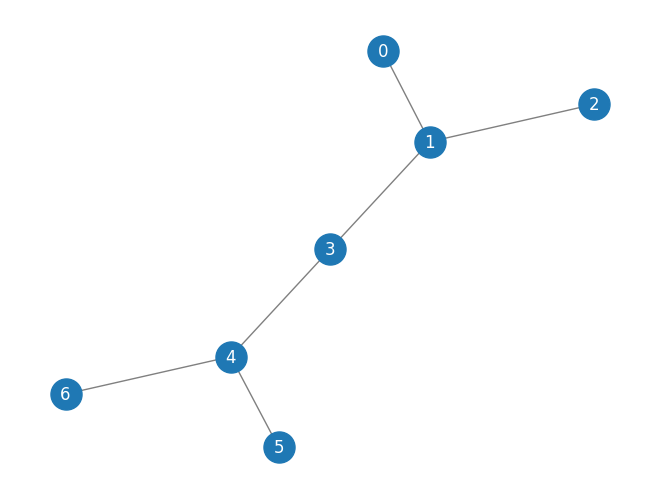

In [6]:
max_cut_graph_edges = [(0, 1), (1, 2), (1, 3), (3, 4), (4, 5), (4, 6)]
n_nodes = 7

max_cut_graph = nx.Graph()
max_cut_graph.add_edges_from(max_cut_graph_edges)
nx.draw(
    max_cut_graph,
    labels={node: node for node in max_cut_graph.nodes()},
    font_size=12,
    font_color="white",
    node_size=500,
    edge_color="gray",
)

The solution for this graph is a simple alternating colouring which we can represent with the following pair of bitstrings. See the two graphs drawn at the end of this notebook. The bitstrings are the binary complement of one another.

In [7]:
expected_result_strings = ["0100100", "1011011"]

Now we need a problem Hamiltionian which reflects the connectivity of our graph. Recall how the problem Hamiltonian is defined.

$$
\begin{equation*}
H_{P(G)} = \frac{1}{2}\sum_{(i, \, j)} (I -Z_i \,Z_j)
\end{equation*}
$$


Four our seven vertex graph, the problem Hamiltonian is the following 


$$
\begin{equation}
H_{P(G)} = 3 I_{(n=7)} -\frac{1}{2} \big[ Z_0 Z_1 + Z_1 Z_2 +Z_1 Z_3 +Z_3 Z_4 +Z_4 Z_5 +Z_4 Z_6  \big]\, .
\end{equation}
$$

The form of the mixer Hamiltonian $H_B$ depends only on the number of nodes in our graph. The evolution operator $U_B$ can be implemented with a layer of `Rx` gates. See the `build_qaoa_instance` function.

In [8]:
%%time
n_shots = 2000
p_value = 3
random_seed = 12345
iterations = 100

qaoa_result, cost_angles, mixer_angles = solve_maxcut_instance(
    n_shots=n_shots,
    iterations=iterations,
    graph=max_cut_graph,
    seed=random_seed,
    p_value=p_value,  # #Cost-mixer layers
)

new highest energy found:  3.1499999999999986
new highest energy found:  3.299999999999997
new highest energy found:  4.306499999999993
new highest energy found:  4.876999999999997
new highest energy found:  4.937499999999999
highest energy:  4.937499999999999
best guess mixer angles:  [0.392 0.247 0.138]
best guess cost angles:  [0.592 0.738 0.608]
CPU times: user 31.2 s, sys: 4.01 s, total: 35.2 s
Wall time: 2min 14s


**Note, there are some performance limitations of the QAOA implementation shown here. The main bottleneck is that the `main` function in `eval_qaoa` energy has to be recompiled for each parameter evaluation (QAOA iteration). In the future, it may be possible to have a `main` function entrypoint which takes arguments. This would mean that the function can be compiled once and then re-computed for different parameter values**. 

Lets define a function that checks that the most frequent measurement outcomes correspond to the expected graph colourings.

In [9]:
def validate_qaoa_experiment(
    result: QsysResult, expected_colourings: tuple[list[str]], n_shots: int
) -> None:
    counts_dict = result.register_counts()["c"]
    sorted_shots = counts_dict.most_common()
    most_common_states = [entry[0] for entry in sorted_shots[:2]]

    if most_common_states == expected_colourings:
        num_successful_shots = sum(entry[1] for entry in sorted_shots[:2])
        print(f"Success ratio: {num_successful_shots / n_shots} ")
    else:
        raise ValueError(
            f"The most frequently measured outcomes {most_common_states} did not correspond to the expected graph colouring."
        )

In [10]:
validate_qaoa_experiment(qaoa_result, expected_result_strings, n_shots)

Success ratio: 0.4205 


Finally, we can plot the most common measurement outcomes. If we have done this correctly then the two most common measurement outcomes should correspond to the graph colourings which solve our instance of the maxcut problem 

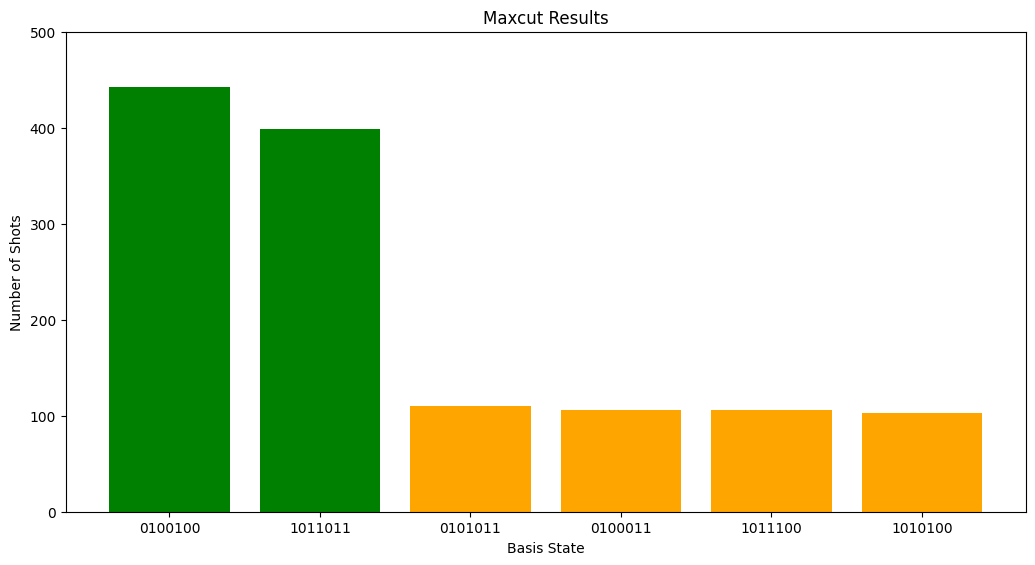

In [11]:
import matplotlib.pyplot as plt


def plot_maxcut_results(result: QsysResult, n_strings: int) -> None:
    """
    Plots Maxcut results in a barchart with the two most common bitstrings highlighted in green.
    """
    counts_dict = result.register_counts()["c"]
    sorted_shots = counts_dict.most_common()
    n_shots = sum(counts_dict.values())

    n_most_common_strings = sorted_shots[:n_strings]
    x_axis_values = [str(entry[0]) for entry in n_most_common_strings]  # basis states
    y_axis_values = [entry[1] for entry in n_most_common_strings]  # counts

    fig = plt.figure()
    ax = fig.add_axes([0, 0, 1.5, 1])
    color_list = ["green"] * 2 + (["orange"] * (len(x_axis_values) - 2))
    ax.bar(
        x=x_axis_values,
        height=y_axis_values,
        color=color_list,
    )
    ax.set_title(label="Maxcut Results")
    plt.ylim([0, 0.25 * n_shots])
    plt.xlabel("Basis State")
    plt.ylabel("Number of Shots")
    plt.show()


plot_maxcut_results(qaoa_result, n_strings=6)

The two green bars correspond to the expected colourings of our seven vertex graph. These colorings are equivalent up to the swapping of blue and red nodes.

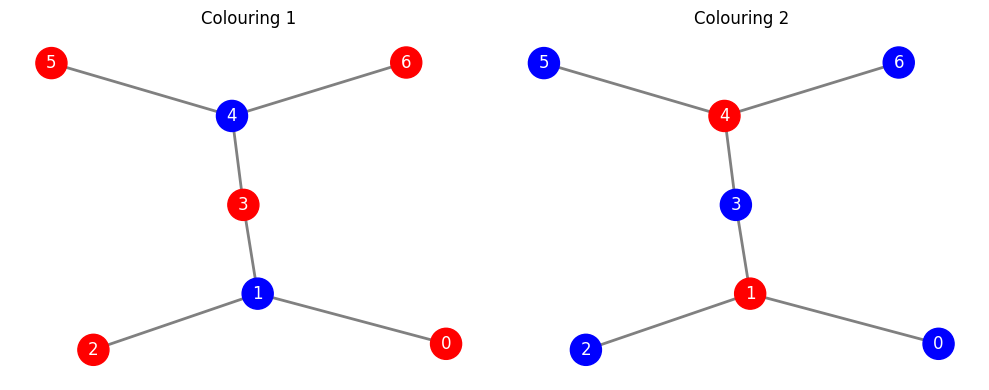

In [12]:
G = nx.Graph()
G.add_edges_from(max_cut_graph_edges)

H = nx.Graph()
H.add_edges_from(max_cut_graph_edges)

# Use same layout for both graphs
pos = nx.spring_layout(G, seed=42)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# First colouring
nx.draw(
    G,
    pos=pos,
    ax=axes[0],
    with_labels=True,
    node_color=["red", "blue", "red", "red", "blue", "red", "red"],
    node_size=500,
    edge_color="gray",
    width=2,
    font_size=12,
    font_color="white",
)
axes[0].set_title("Colouring 1")
axes[0].set_axis_off()

# Second colouring
nx.draw(
    H,
    pos=pos,
    ax=axes[1],
    with_labels=True,
    node_color=["blue", "red", "blue", "blue", "red", "blue", "blue"],
    node_size=500,
    edge_color="gray",
    width=2,
    font_size=12,
    font_color="white",
)
axes[1].set_title("Colouring 2")
axes[1].set_axis_off()

plt.tight_layout()
plt.show()